# Analysis of TMC Data Shapley Results (`tmc_shapley3`)

This notebook analyzes outputs from `run_tmc_shapley_by_islands` using the TMC config.
It is designed to work with both complete targets (with uncertainty aggregates) and partial targets (repeat-level only).

In [2]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [3]:
# Resolve workspace root robustly
cwd = Path.cwd().resolve()
workspace_root = cwd
if not (workspace_root / "outputs" / "tmc_shapley3").exists():
    for parent in [cwd, *cwd.parents]:
        if (parent / "outputs" / "tmc_shapley3").exists():
            workspace_root = parent
            break

base_dir = workspace_root / "outputs" / "tmc_shapley3"
if not base_dir.exists():
    raise FileNotFoundError(f"Could not find results folder: {base_dir}")

print(f"Workspace root: {workspace_root}")
print(f"Using results:   {base_dir}")

Workspace root: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis
Using results:   C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\tmc_shapley3


In [4]:
def parse_target_from_name(name: str):
    m = re.search(r"target_(\d+)", name)
    return int(m.group(1)) if m else None

def load_json(path: Path):
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def safe_read_csv(path: Path):
    return pd.read_csv(path) if path.exists() else None

def collect_target_dirs(base: Path):
    targets = {}
    for d in sorted(base.glob("island_*")):
        if not d.is_dir():
            continue
        try:
            target = int(d.name.split("_")[-1])
        except ValueError:
            continue
        targets[target] = d
    return targets

target_dirs = collect_target_dirs(base_dir)
target_dirs

{0: WindowsPath('C:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/Master_thesis/outputs/tmc_shapley3/island_0'),
 5: WindowsPath('C:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/Master_thesis/outputs/tmc_shapley3/island_5')}

In [5]:
def load_target_data(target: int, folder: Path):
    data = {"target": target, "folder": folder}

    data["uncertainty_summary"] = load_json(folder / f"uncertainty_summary_target_{target}.json")
    data["shapley_uncertainty"] = safe_read_csv(folder / f"shapley_uncertainty_target_{target}.csv")
    data["add_uncertainty"] = safe_read_csv(folder / f"add_curve_uncertainty_target_{target}.csv")
    data["remove_uncertainty"] = safe_read_csv(folder / f"remove_curve_uncertainty_target_{target}.csv")

    repeats = []
    for rep_dir in sorted(folder.glob("repeat_*")):
        if not rep_dir.is_dir():
            continue
        rep_num = int(rep_dir.name.split("_")[-1])
        row = {
            "repeat": rep_num,
            "shapley": safe_read_csv(rep_dir / f"shapley_island_values_target_{target}.csv"),
            "add_curve": safe_read_csv(rep_dir / f"add_curve_target_{target}.csv"),
            "remove_curve": safe_read_csv(rep_dir / f"remove_curve_target_{target}.csv"),
            "tmc_summary": load_json(rep_dir / f"tmc_summary_target_{target}.json"),
        }
        repeats.append(row)

    data["repeats"] = repeats
    return data

targets_data = {t: load_target_data(t, d) for t, d in target_dirs.items()}

manifest_rows = []
for t, obj in targets_data.items():
    manifest_rows.append({
        "target": t,
        "n_repeats": len(obj["repeats"]),
        "has_uncertainty_summary": obj["uncertainty_summary"] is not None,
        "has_shapley_uncertainty": obj["shapley_uncertainty"] is not None,
        "has_add_uncertainty": obj["add_uncertainty"] is not None,
        "has_remove_uncertainty": obj["remove_uncertainty"] is not None,
    })

manifest = pd.DataFrame(manifest_rows).sort_values("target")
manifest

,target,n_repeats,has_uncertainty_summary,has_shapley_uncertainty,has_add_uncertainty,has_remove_uncertainty
0,0,5,True,True,True,True
1,5,1,False,False,False,False


## 1) TMC run diagnostics across repeats

,target,repeat,target_name,v_full,n_permutations,n_utility_evals,cache_hit_rate,n_truncated,use_truncation
0,0,0,Nesøy,0.364593,20,265,0.119601,0,False
1,0,1,Nesøy,0.207345,20,260,0.136213,0,False
2,0,2,Nesøy,0.153546,20,261,0.132890,0,False
3,0,3,Nesøy,0.471609,20,260,0.136213,0,False
4,0,4,Nesøy,0.293704,20,263,0.126246,0,False


,target,target_name,repeats,v_full_mean,v_full_std,evals_mean,cache_hit_mean
0,0,Nesøy,5,0.298160,0.126173,261.8,0.130233
1,5,Hestmannøy,1,0.179535,NaN,266.0,0.116279


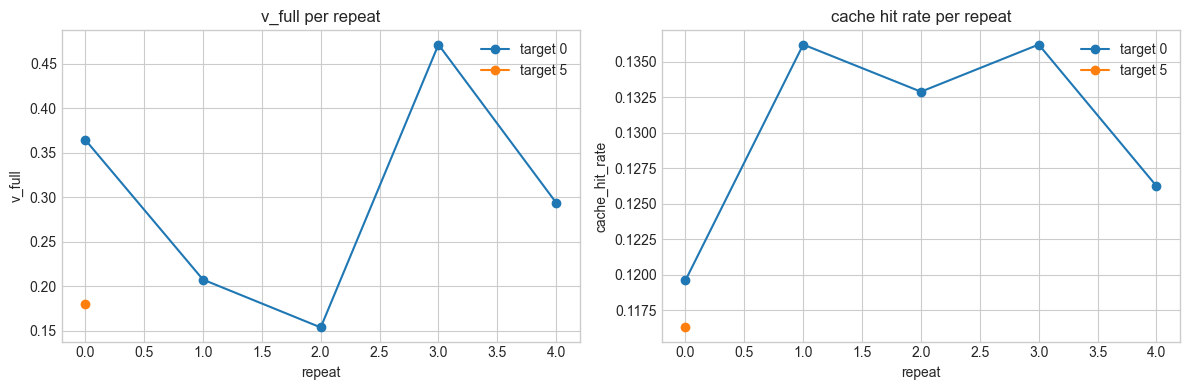

In [6]:
tmc_rows = []
for target, obj in targets_data.items():
    for rep in obj["repeats"]:
        s = rep["tmc_summary"]
        if s is None:
            continue
        tmc_rows.append({
            "target": target,
            "repeat": rep["repeat"],
            "target_name": s.get("target_island_name"),
            "v_full": s.get("v_full"),
            "n_permutations": s.get("n_permutations"),
            "n_utility_evals": s.get("n_utility_evals"),
            "cache_hit_rate": s.get("cache_hit_rate"),
            "n_truncated": s.get("n_truncated"),
            "use_truncation": s.get("use_truncation"),
        })

tmc_df = pd.DataFrame(tmc_rows).sort_values(["target", "repeat"])
display(tmc_df.head())

if not tmc_df.empty:
    summary = tmc_df.groupby(["target", "target_name"], as_index=False).agg(
        repeats=("repeat", "count"),
        v_full_mean=("v_full", "mean"),
        v_full_std=("v_full", "std"),
        evals_mean=("n_utility_evals", "mean"),
        cache_hit_mean=("cache_hit_rate", "mean"),
    )
    display(summary)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for target, g in tmc_df.groupby("target"):
        axes[0].plot(g["repeat"], g["v_full"], marker="o", label=f"target {target}")
        axes[1].plot(g["repeat"], g["cache_hit_rate"], marker="o", label=f"target {target}")

    axes[0].set_title("v_full per repeat")
    axes[0].set_xlabel("repeat")
    axes[0].set_ylabel("v_full")
    axes[1].set_title("cache hit rate per repeat")
    axes[1].set_xlabel("repeat")
    axes[1].set_ylabel("cache_hit_rate")
    axes[0].legend(loc="best")
    axes[1].legend(loc="best")
    plt.tight_layout()
    plt.show()

## 2) Shapley values by target (mean per individual)

,target_island,source_island,source_island_name,n_island,phi_mean,phi_std,phi_p05,phi_p95,phi_per_ind_mean,phi_per_ind_std,n_repeats,rank_mean_phi_per_ind
8,0,9,Sleneset,166,0.040154,0.035185,-0.005052,0.071436,0.000242,0.000212,5,1
2,0,3,Selvær,194,0.037318,0.022878,0.019009,0.068158,0.000192,0.000118,5,2
4,0,5,Hestmannøy,1078,0.194321,0.202669,-0.038983,0.415653,0.000180,0.000188,5,3
9,0,10,Aldra,173,0.022174,0.035917,-0.019465,0.058575,0.000128,0.000208,5,4
10,0,11,Southern 1,583,0.050491,0.052890,0.003415,0.112190,0.000087,0.000091,5,5
3,0,4,Gjerøy,558,0.039468,0.089154,-0.045540,0.141656,0.000071,0.000160,5,6
12,0,13,Southern 3,584,0.034879,0.049890,-0.033702,0.069087,0.000060,0.000085,5,7
5,0,6,Indre Kvarøy,356,0.015328,0.034863,-0.024337,0.055171,0.000043,0.000098,5,8
11,0,12,Southern 2,397,0.006046,0.044336,-0.044863,0.058219,0.000015,0.000112,5,9
14,0,15,Southern 5,202,0.001639,0.034601,-0.042883,0.034185,0.000008,0.000171,5,10


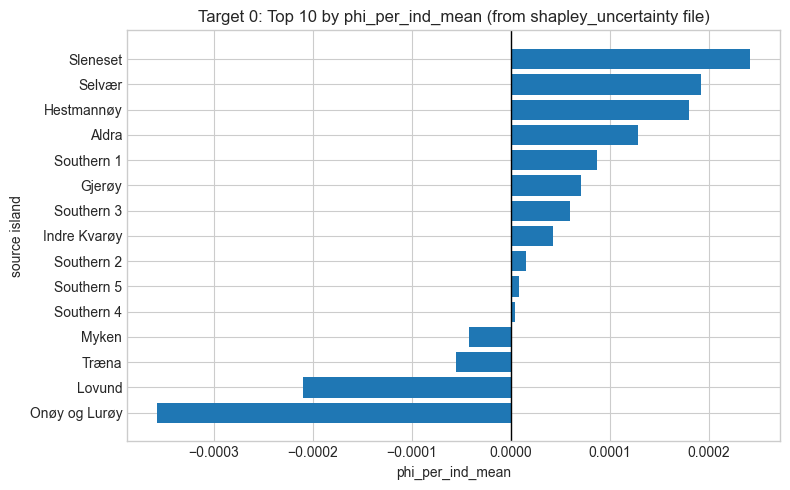

,target_island,source_island,source_island_name,n_island,phi_mean,phi_std,phi_per_ind_mean,phi_per_ind_std,n_repeats
9,5,10,Aldra,173,0.034142,NaN,0.000197,NaN,1
8,5,9,Sleneset,166,0.027717,NaN,0.000167,NaN,1
1,5,1,Myken,92,0.011990,NaN,0.000130,NaN,1
5,5,6,Indre Kvarøy,356,0.039804,NaN,0.000112,NaN,1
7,5,8,Lovund,158,0.017194,NaN,0.000109,NaN,1
4,5,4,Gjerøy,558,0.044913,NaN,0.000080,NaN,1
11,5,12,Southern 2,397,0.022874,NaN,0.000058,NaN,1
12,5,13,Southern 3,584,0.030808,NaN,0.000053,NaN,1
2,5,2,Træna,292,0.009332,NaN,0.000032,NaN,1
10,5,11,Southern 1,583,0.018084,NaN,0.000031,NaN,1


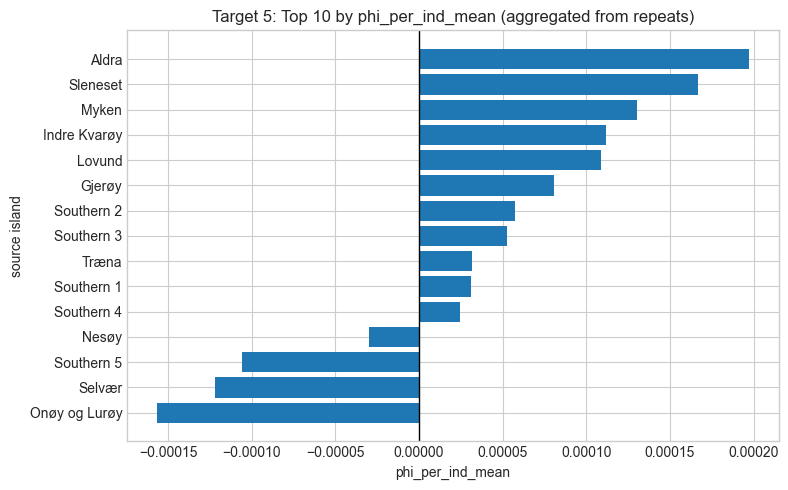

In [7]:
def shapley_from_repeats(obj):
    parts = []
    for rep in obj["repeats"]:
        d = rep["shapley"]
        if d is None:
            continue
        tmp = d.copy()
        tmp["repeat"] = rep["repeat"]
        parts.append(tmp)
    if not parts:
        return None
    long = pd.concat(parts, ignore_index=True)
    agg = long.groupby(["target_island", "source_island", "source_island_name", "n_island"], as_index=False).agg(
        phi_mean=("phi", "mean"),
        phi_std=("phi", "std"),
        phi_per_ind_mean=("phi_per_individual", "mean"),
        phi_per_ind_std=("phi_per_individual", "std"),
        n_repeats=("repeat", "count"),
    )
    return agg.sort_values("phi_per_ind_mean", ascending=False)

for target, obj in targets_data.items():
    if obj["shapley_uncertainty"] is not None:
        shap = obj["shapley_uncertainty"].copy()
        shap = shap.sort_values("phi_per_ind_mean", ascending=False)
        title_suffix = "(from shapley_uncertainty file)"
    else:
        shap = shapley_from_repeats(obj)
        title_suffix = "(aggregated from repeats)"

    if shap is None or shap.empty:
        print(f"No shapley data for target {target}")
        continue

    display(shap.head(10))

    top = shap.head(15).iloc[::-1]
    plt.figure(figsize=(8, 5))
    plt.barh(top["source_island_name"], top["phi_per_ind_mean"])
    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"Target {target}: Top 10 by phi_per_ind_mean {title_suffix}")
    plt.xlabel("phi_per_ind_mean")
    plt.ylabel("source island")
    plt.tight_layout()
    plt.show()

## 3) Add/remove curves: shapley ordering vs random

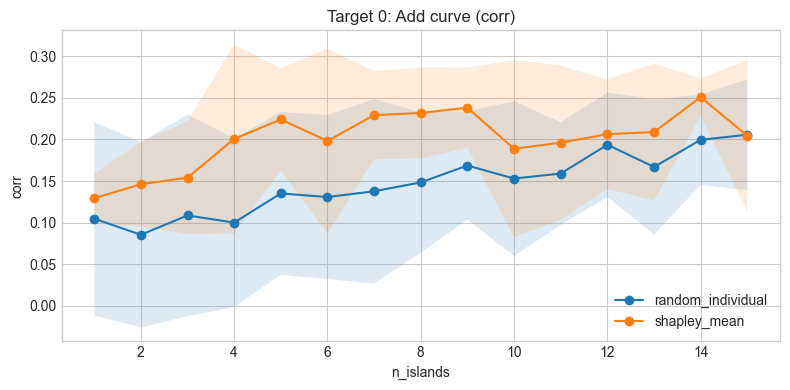

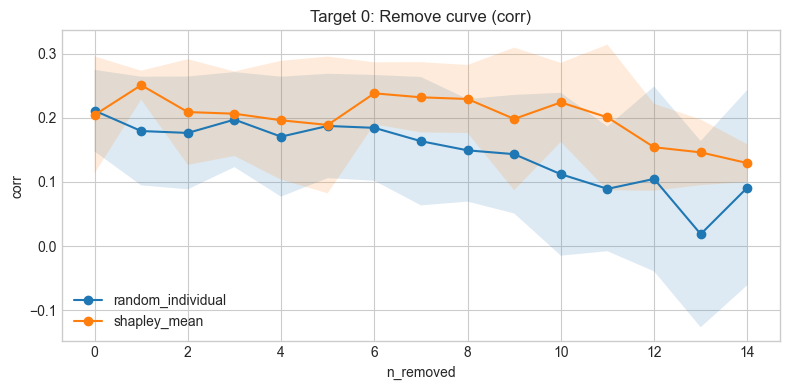

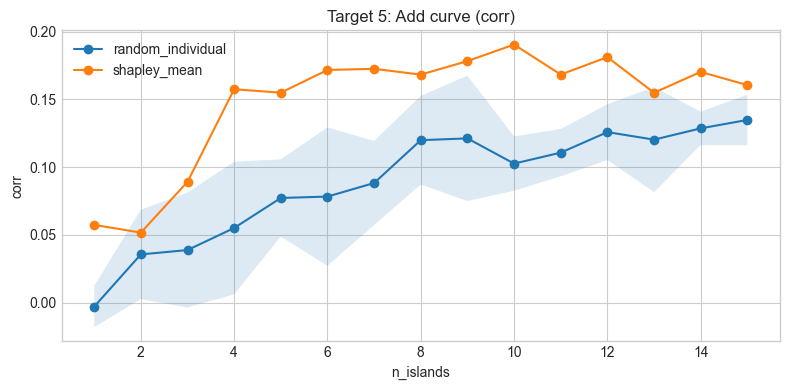

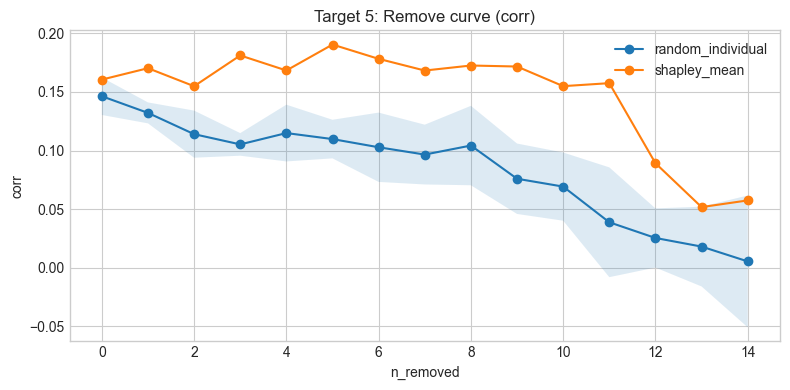

In [8]:
def infer_xcol(df):
    for col in ["n_removed", "n_islands", "n_individuals", "x"]:
        if col in df.columns:
            return col
    raise KeyError(f"No x-axis column found. Available columns: {list(df.columns)}")


def aggregate_curves_from_repeats(obj, which="add_curve"):
    parts = []
    for rep in obj["repeats"]:
        d = rep.get(which)
        if d is None:
            continue
        tmp = d.copy()
        tmp["repeat"] = rep["repeat"]
        parts.append(tmp)

    if not parts:
        return None

    long = pd.concat(parts, ignore_index=True)
    xcol = infer_xcol(long)

    corr_col = "corr_eval" if "corr_eval" in long.columns else "corr_mean"
    mse_col = "mse_adj" if "mse_adj" in long.columns else "mse_mean"

    stats = long.groupby(["method", xcol], as_index=False).agg(
        corr_mean=(corr_col, "mean"),
        corr_std=(corr_col, "std"),
        mse_mean=(mse_col, "mean"),
        mse_std=(mse_col, "std"),
    )
    return stats


for target, obj in targets_data.items():
    add_stats = obj["add_uncertainty"].copy() if obj["add_uncertainty"] is not None else aggregate_curves_from_repeats(obj, "add_curve")
    rem_stats = obj["remove_uncertainty"].copy() if obj["remove_uncertainty"] is not None else aggregate_curves_from_repeats(obj, "remove_curve")

    if add_stats is not None and not add_stats.empty:
        xcol = infer_xcol(add_stats)
        plt.figure(figsize=(8, 4))
        for method, g in add_stats.groupby("method"):
            g = g.sort_values(xcol)
            plt.plot(g[xcol], g["corr_mean"], marker="o", label=method)
            if "corr_std" in g.columns and g["corr_std"].notna().any():
                y1 = g["corr_mean"] - g["corr_std"]
                y2 = g["corr_mean"] + g["corr_std"]
                plt.fill_between(g[xcol], y1, y2, alpha=0.15)
        plt.title(f"Target {target}: Add curve (corr)")
        plt.xlabel(xcol)
        plt.ylabel("corr")
        plt.legend()
        plt.tight_layout()
        plt.show()

    if rem_stats is not None and not rem_stats.empty:
        xcol = infer_xcol(rem_stats)
        plt.figure(figsize=(8, 4))
        for method, g in rem_stats.groupby("method"):
            g = g.sort_values(xcol)
            plt.plot(g[xcol], g["corr_mean"], marker="o", label=method)
            if "corr_std" in g.columns and g["corr_std"].notna().any():
                y1 = g["corr_mean"] - g["corr_std"]
                y2 = g["corr_mean"] + g["corr_std"]
                plt.fill_between(g[xcol], y1, y2, alpha=0.15)
        plt.title(f"Target {target}: Remove curve (corr)")
        plt.xlabel(xcol)
        plt.ylabel("corr")
        plt.legend()
        plt.tight_layout()
        plt.show()

## 4) Quick takeaways table

In [9]:
rows = []
for target, obj in targets_data.items():
    # best source island by phi_per_ind_mean
    if obj["shapley_uncertainty"] is not None:
        s = obj["shapley_uncertainty"].sort_values("phi_per_ind_mean", ascending=False)
    else:
        s = shapley_from_repeats(obj)

    best_name = None
    best_phi = np.nan
    if s is not None and not s.empty:
        best_name = s.iloc[0]["source_island_name"]
        best_phi = s.iloc[0]["phi_per_ind_mean"]

    v_full_mean = np.nan
    cache_hit_mean = np.nan
    if obj["repeats"]:
        vals_v, vals_c = [], []
        for rep in obj["repeats"]:
            ts = rep["tmc_summary"]
            if ts is None:
                continue
            if ts.get("v_full") is not None:
                vals_v.append(ts.get("v_full"))
            if ts.get("cache_hit_rate") is not None:
                vals_c.append(ts.get("cache_hit_rate"))
        if vals_v:
            v_full_mean = float(np.mean(vals_v))
        if vals_c:
            cache_hit_mean = float(np.mean(vals_c))

    rows.append({
        "target": target,
        "n_repeats": len(obj["repeats"]),
        "best_source_by_phi_per_ind": best_name,
        "best_phi_per_ind": best_phi,
        "v_full_mean": v_full_mean,
        "cache_hit_rate_mean": cache_hit_mean,
    })

takeaways = pd.DataFrame(rows).sort_values("target")
takeaways

,target,n_repeats,best_source_by_phi_per_ind,best_phi_per_ind,v_full_mean,cache_hit_rate_mean
0,0,5,Sleneset,0.000242,0.298160,0.130233
1,5,1,Aldra,0.000197,0.179535,0.116279


### Notes
- `island_0` includes uncertainty aggregate files (`*_uncertainty_target_0.*`) produced across 5 repeats.
- `island_5` currently has one repeat folder only, so uncertainty bands are estimated only from available repeat-level data.
- If additional repeats are generated for `island_5`, rerun this notebook to update all summaries automatically.